# 🔍 Profiling de l'API de prédiction — Guide pour débutants

## 📚 Qu'est-ce que le profiling ?

Le **profiling** est une technique qui permet de **mesurer le temps d'exécution** de chaque partie d'un programme. C'est comme un chronomètre ultra-précis qui enregistre combien de temps prend chaque fonction.

## 🎯 Pourquoi on fait du profiling ?

Imagine que ton API met **50 ms** à répondre, mais tu ne sais pas **où** elle passe tout ce temps :
- Est-ce le chargement des données ? 🔄
- Est-ce le modèle de prédiction ? 🤖
- Est-ce la transformation des données ? 🔧

Le profiling répond à cette question en te montrant **ligne par ligne** où le temps est consommé.

## 🚀 Objectif de ce notebook

Dans ce notebook, on va profiler la fonction `_predict()` de notre API Flask pour :
1. ⏱️ Mesurer le temps d'exécution total
2. 📊 Identifier les **20 fonctions les plus lentes**
3. 🔴 Trouver le **goulot d'étranglement** (bottleneck)
4. 💡 Proposer des **pistes d'optimisation**

**Prêt ? C'est parti ! 🚀**

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📦 IMPORTS ET CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════

# ── Imports pour le profiling ──
import cProfile      # 🔍 Outil de profiling de Python
import pstats        # 📊 Pour formatter les résultats
import io            # Pour capturer les résultats dans un buffer
from pstats import SortKey  # Pour trier les résultats

# ── Imports système ──
import sys
import os

# ── Ajouter le dossier racine du projet au path ──
# Ceci permet d'importer app.py depuis le notebook
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# ── Importer la fonction à profiler ──
from app import _predict  # ⚡ La fonction interne de notre API

# ── Imports pour la visualisation ──
import matplotlib.pyplot as plt
%matplotlib inline

print("✅ Imports OK — fonction _predict() prête pour le profiling")

✅ Imports OK — fonction _predict() prête pour le profiling


---

## 🔥 2. Warm-up du modèle (comme en production)

**Pourquoi un warm-up ?** 🤔

Lors du **premier appel**, Python charge plein de choses en mémoire :
- Le modèle LightGBM 🤖
- Le preprocesseur (scaler, encodeur) 🔧
- Les bibliothèques (numpy, pandas) 📚

Ces chargements prennent du temps et **fausseraient nos mesures**. On fait donc 3 appels "à blanc" pour tout charger AVANT de lancer le profiling.

**Astuce** : C'est exactement ce qui se passe en production — le 1er appel est lent, les suivants sont rapides ! ⚡

---

## 📦 1. Imports et configuration

On commence par importer les outils nécessaires pour le profiling :
- **`cProfile`** : le moteur de profiling de Python 🔍
- **`pstats`** : pour formatter les résultats 📋
- **`_predict()`** : la fonction de notre API qu'on va analyser ⚡

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 🔥 WARM-UP DU MODÈLE
# ═══════════════════════════════════════════════════════════════════════════

import json
import time

# ── Définition d'un échantillon JSON réaliste ──
# Ces features correspondent exactement à celles envoyées en production
SAMPLE_JSON = json.dumps({
    "CODE_GENDER": 0,                      # 0 = Femme, 1 = Homme
    "FLAG_OWN_CAR": 0,                     # 0 = Pas de voiture
    "FLAG_OWN_REALTY": 1,                  # 1 = Propriétaire immobilier
    "CNT_CHILDREN": 0,                     # Nombre d'enfants
    "AMT_INCOME_TOTAL": 135000.0,          # Revenu annuel
    "AMT_CREDIT": 406597.5,                # Montant du crédit demandé
    "AMT_ANNUITY": 20250.0,                # Annuité (remboursement annuel)
    "AMT_GOODS_PRICE": 351000.0,           # Prix du bien financé
    "REGION_POPULATION_RELATIVE": 0.035792,
    "DAYS_BIRTH": -14103,                  # Âge (en jours négatifs)
    "DAYS_EMPLOYED": -3005,                # Ancienneté emploi (en jours)
    "DAYS_REGISTRATION": -4850.0,
    "DAYS_ID_PUBLISH": -2767,
    "OWN_CAR_AGE": None,                   # Pas de voiture = None
    "FLAG_MOBIL": 1,
    "FLAG_EMP_PHONE": 1,
    "FLAG_WORK_PHONE": 0,
    "FLAG_CONT_MOBILE": 1,
    "FLAG_PHONE": 1,
    "FLAG_EMAIL": 0,
    "CNT_FAM_MEMBERS": 2.0,
    "REGION_RATING_CLIENT": 2,
    "REGION_RATING_CLIENT_W_CITY": 2,
    "HOUR_APPR_PROCESS_START": 10,         # Heure de la demande
    "REG_REGION_NOT_LIVE_REGION": 0,
    "REG_REGION_NOT_WORK_REGION": 0,
    "LIVE_REGION_NOT_WORK_REGION": 0,
    "REG_CITY_NOT_LIVE_CITY": 0,
    "EXT_SOURCE_1": 0.502130,              # Scores externes (bureaux de crédit)
    "EXT_SOURCE_2": 0.585605,
    "EXT_SOURCE_3": 0.310653,
    "DAYS_LAST_PHONE_CHANGE": -1134.0,
    "AMT_REQ_CREDIT_BUREAU_YEAR": 1.0      # Nombre de demandes de crédit cette année
})

# ── Warm-up : 3 appels pour charger modèle + caches ──
print("🔄 Warm-up en cours (3 appels)...")
for _ in range(3):
    _predict(SAMPLE_JSON)  # ⚡ Appel à la fonction de prédiction

# ── Vérification : est-ce que ça marche ? ──
reponse_test = _predict(SAMPLE_JSON)
print(f"✅ Warm-up terminé — Exemple de réponse :\n{reponse_test}")

🔄 Warm-up en cours (3 appels)...
Loaded local LightGBM model from /home/valentin/Env_Python/OC_P6/models/lightgbm.txt
[LOG] {"timestamp": "2026-02-25T14:43:53.936394Z", "input_raw": "{\"CODE_GENDER\": 0, \"FLAG_OWN_CAR\": 0, \"FLAG_OWN_REALTY\": 1, \"CNT_CHILDREN\": 0, \"AMT_INCOME_TOTAL\": 135000.0, \"AMT_CREDIT\": 406597.5, \"AMT_ANNUITY\": 20250.0, \"AMT_GOODS_PRICE\": 351000.0, \"REGION_POPULATION_RELATIVE\": 0.035792, \"DAYS_BIRTH\": -14103, \"DAYS_EMPLOYED\": -3005, \"DAYS_REGISTRATION\": -4850.0, \"DAYS_ID_PUBLISH\": -2767, \"OWN_CAR_AGE\": null, \"FLAG_MOBIL\": 1, \"FLAG_EMP_PHONE\": 1, \"FLAG_WORK_PHONE\": 0, \"FLAG_CONT_MOBILE\": 1, \"FLAG_PHONE\": 1, \"FLAG_EMAIL\": 0, \"CNT_FAM_MEMBERS\": 2.0, \"REGION_RATING_CLIENT\": 2, \"REGION_RATING_CLIENT_W_CITY\": 2, \"HOUR_APPR_PROCESS_START\": 10, \"REG_REGION_NOT_LIVE_REGION\": 0, \"REG_REGION_NOT_WORK_REGION\": 0, \"LIVE_REGION_NOT_WORK_REGION\": 0, \"REG_CITY_NOT_LIVE_CITY\": 0, \"EXT_SOURCE_1\": 0.50213, \"EXT_SOURCE_2\": 0.585

---

## ⏱️ 3. Lancement du profiling sur 50 prédictions

Maintenant qu'on a fait le warm-up, on lance le **vrai profiling** ! 🔥

**Comment ça marche ?**
1. On active le profiler avec `pr.enable()` 🟢
2. On appelle `_predict()` **50 fois** (pour avoir une moyenne fiable)
3. On désactive le profiler avec `pr.disable()` 🔴
4. On calcule le **temps moyen par appel** 📊

**Pourquoi 50 appels ?** Pour lisser les variations et avoir une mesure précise ⚖️

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# ⏱️ LANCEMENT DU PROFILING
# ═══════════════════════════════════════════════════════════════════════════

N_APPELS = 50  # 📊 Nombre d'appels pour la moyenne

print(f"🔥 Lancement du profiling sur {N_APPELS} prédictions...\n")

# ── Mesure du temps mural (temps réel écoulé) ──
debut = time.perf_counter()  # 🕐 Démarrage du chronomètre

# ── Création et activation du profiler ──
pr = cProfile.Profile()  # 🔍 Création du profiler
pr.enable()              # 🟢 Activation : on enregistre tout !

# ── Boucle de prédictions (c'est ici qu'on profile) ──
for _ in range(N_APPELS):
    _predict(SAMPLE_JSON)  # ⚡ Même fonction que dans les logs de production

# ── Désactivation du profiler ──
pr.disable()             # 🔴 Stop : on arrête l'enregistrement
fin = time.perf_counter()  # 🕐 Fin du chronomètre

# ── Calcul des métriques globales ──
temps_total_ms = (fin - debut) * 1000        # Temps total en millisecondes
temps_moyen_ms = temps_total_ms / N_APPELS   # Temps moyen par appel

print(f"⏱️  Temps total profiling  : {temps_total_ms:.1f} ms")
print(f"📊 Temps moyen par appel  : {temps_moyen_ms:.2f} ms")
print("\n✅ Profiling terminé — affichage du rapport ci-dessous")

🔥 Lancement du profiling sur 50 prédictions...
[LOG] {"timestamp": "2026-02-25T14:43:54.151427Z", "input_raw": "{\"CODE_GENDER\": 0, \"FLAG_OWN_CAR\": 0, \"FLAG_OWN_REALTY\": 1, \"CNT_CHILDREN\": 0, \"AMT_INCOME_TOTAL\": 135000.0, \"AMT_CREDIT\": 406597.5, \"AMT_ANNUITY\": 20250.0, \"AMT_GOODS_PRICE\": 351000.0, \"REGION_POPULATION_RELATIVE\": 0.035792, \"DAYS_BIRTH\": -14103, \"DAYS_EMPLOYED\": -3005, \"DAYS_REGISTRATION\": -4850.0, \"DAYS_ID_PUBLISH\": -2767, \"OWN_CAR_AGE\": null, \"FLAG_MOBIL\": 1, \"FLAG_EMP_PHONE\": 1, \"FLAG_WORK_PHONE\": 0, \"FLAG_CONT_MOBILE\": 1, \"FLAG_PHONE\": 1, \"FLAG_EMAIL\": 0, \"CNT_FAM_MEMBERS\": 2.0, \"REGION_RATING_CLIENT\": 2, \"REGION_RATING_CLIENT_W_CITY\": 2, \"HOUR_APPR_PROCESS_START\": 10, \"REG_REGION_NOT_LIVE_REGION\": 0, \"REG_REGION_NOT_WORK_REGION\": 0, \"LIVE_REGION_NOT_WORK_REGION\": 0, \"REG_CITY_NOT_LIVE_CITY\": 0, \"EXT_SOURCE_1\": 0.50213, \"EXT_SOURCE_2\": 0.585605, \"EXT_SOURCE_3\": 0.310653, \"DAYS_LAST_PHONE_CHANGE\": -1134.0, \

---

## 📋 4. Rapport textuel du profiling (Top 15)

Le profiler a enregistré **toutes les fonctions appelées**. On va d'abord afficher un rapport textuel avec les **15 fonctions les plus lentes**.

**Comment lire ce rapport ?**
- **ncalls** : nombre de fois que la fonction a été appelée
- **tottime** : temps passé **dans** la fonction (sans les sous-fonctions)
- **cumtime** : temps **cumulé** (avec toutes les sous-fonctions) ⚠️ **C'EST LA COLONNE IMPORTANTE !**

Plus le `cumtime` est élevé, plus la fonction est un goulot d'étranglement ! 🔴

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📋 RAPPORT TEXTUEL DU PROFILING
# ═══════════════════════════════════════════════════════════════════════════

TOP_N = 15  # 🔢 On affiche les 15 fonctions les plus lentes

# ── Capture du rapport dans un buffer (pour l'afficher proprement) ──
buffer = io.StringIO()  # Créer un buffer en mémoire
stats = pstats.Stats(pr, stream=buffer)  # Créer les stats depuis le profiler

# ── Formatage du rapport ──
stats.strip_dirs()  # Supprimer les chemins absolus (plus lisible)
stats.sort_stats(SortKey.CUMULATIVE)  # ⚠️ Tri par temps CUMULÉ (le plus important !)
stats.print_stats(TOP_N)  # Afficher les TOP_N fonctions

# ── Récupération du rapport formaté ──
rapport = buffer.getvalue()

# ── Affichage avec un cadre joli ──
print("═" * 70)
print(f"       📋 RAPPORT PROFILING — TOP {TOP_N} FONCTIONS (temps cumulé)")
print("═" * 70)
print(rapport)
print("═" * 70)
print(f"⏱️  Rappel — Temps total  : {temps_total_ms:.1f} ms")
print(f"📊 Rappel — Temps moyen  : {temps_moyen_ms:.2f} ms")
print("═" * 70)

══════════════════════════════════════════════════════════════════════
       📋 RAPPORT PROFILING — TOP 15 FONCTIONS (temps cumulé)
══════════════════════════════════════════════════════════════════════
         13055924 function calls (12571167 primitive calls) in 4.648 seconds

   Ordered by: cumulative time
   List reduced from 629 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/2    0.000    0.000    4.642    2.321 interactiveshell.py:3665(run_code)
      3/2    0.001    0.000    4.642    2.321 {built-in method builtins.exec}
        1    0.014    0.014    4.636    4.636 304244700.py:1(<module>)
       50    0.041    0.001    4.466    0.089 app.py:307(_predict)
    39950    0.090    0.000    1.985    0.000 frame.py:4282(__setitem__)
    39950    0.045    0.000    1.852    0.000 frame.py:4525(_set_item)
    39950    0.042    0.000    1.563    0.000 frame.py:4492(_set_item_mgr)
    39950    0.042    0.000    1.434    0.00

---

## 📊 5. Visualisation graphique — Top 20 fonctions

Le rapport textuel est utile, mais un graphique est **10 fois plus clair** ! 🎨

On va créer un **graphique en barres horizontales** avec :
- 🔴 **Rouge** : les fonctions les plus lentes (goulots)
- 🔵 **Bleu** : les fonctions rapides
- ⏱️ **Temps en ms** affiché sur chaque barre

**Astuce** : Regarde tout en haut du graphique — c'est là que se cache le goulot principal ! 🔍

📋 Top 20 fonctions les plus coûteuses (par temps cumulé)
                                                               label  appels  t_propre (ms)  t_cumulé (ms)
run_code()                      [interactiveshell.py : L3665]   · 3×       3       0.009600    4642.458555
                    <built-in method builtins.exec>  [~ : L0]   · 3×       3       0.620399    4642.449655
          <module>                        [304244700.py : L1]   · 1×       1      14.056403    4636.241706
             _predict()                      [app.py : L307]   · 50×      50      40.948959    4465.778651
       __setitem__()                   [frame.py : L4282]   · 39950×   39950      90.093506    1984.646909
       _set_item()                     [frame.py : L4525]   · 39950×   39950      45.259302    1852.004282
       _set_item_mgr()                 [frame.py : L4492]   · 39950×   39950      42.053928    1563.481588
       _iset_item_mgr()                [frame.py : L4481]   · 39950×   39950      41.66

/tmp/ipykernel_50810/1876020190.py:104: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_50810/1876020190.py:105: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.savefig("../reports/plots/profiling_top20.png", dpi=150, bbox_inches="tight")
/home/valentin/Env_Python/OC_P6/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


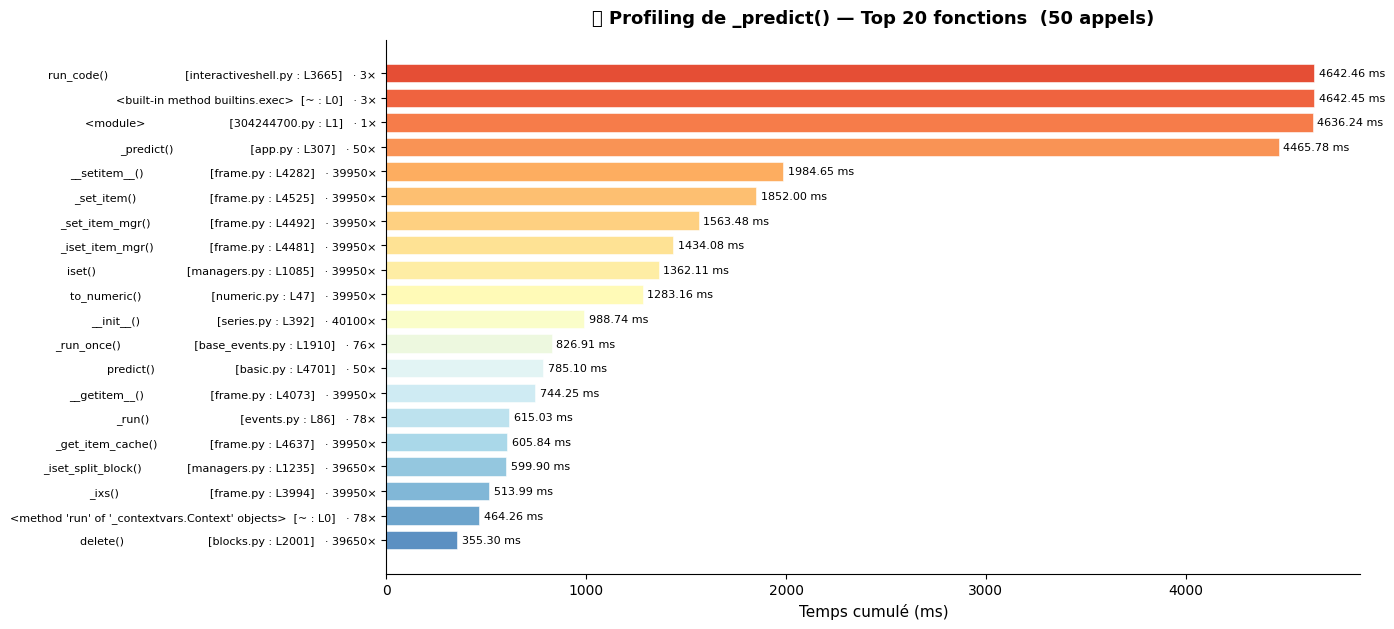

💾 Graphique sauvegardé : reports/plots/profiling_top20.png

🔴 Goulot principal : run_code()  [interactiveshell.py : L3665]  → 4642.46 ms cumulé


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 📊 VISUALISATION GRAPHIQUE — TOP 20 FONCTIONS
# ═══════════════════════════════════════════════════════════════════════════

import re
import pandas as pd

TOP_N = 20  # 🔢 Limiter au top 20 pour la lisibilité

# ── Extraction des données brutes du profiler ──
# Le profiler stocke : {(fichier, ligne, nom): (appels, temps, ...)}
stats_obj = pstats.Stats(pr)
stats_obj.strip_dirs()  # Retirer les chemins absolus
stats_obj.sort_stats(SortKey.CUMULATIVE)  # Trier par temps cumulé

# ── Construction d'un DataFrame Pandas pour faciliter la manipulation ──
lignes = []
for (fichier, numligne, nom), (cc, nc, tt, ct, _) in stats_obj.stats.items():
    lignes.append({
        "nom_court": nom,                  # Nom de la fonction
        "fichier": fichier,                # Fichier source
        "numligne": numligne,              # Numéro de ligne
        "appels": nc,                      # Nombre d'appels
        "temps_propre_ms": tt * 1000,      # Temps propre en ms
        "temps_cumule_ms": ct * 1000,      # Temps cumulé en ms ⚠️
    })

# ── Création du DataFrame et tri par temps cumulé ──
df_stats = pd.DataFrame(lignes)
df_stats = df_stats.sort_values("temps_cumule_ms", ascending=False).reset_index(drop=True)

# ── Limiter au TOP_N ──
df_stats = df_stats.head(TOP_N)

# ── Construction d'un label explicite pour chaque fonction ──
# Format : "nom_fonction()   [fichier.py : ligne N]   · K appels"
def construire_label(row):
    # Ajouter () sauf pour les builtins entre <>
    if row["nom_court"].startswith("<"):
        nom = row["nom_court"]
    else:
        nom = f"{row['nom_court']}()"
    
    # Garder seulement le nom du fichier (sans le chemin complet)
    fichier = row["fichier"].split("/")[-1] if "/" in row["fichier"] else row["fichier"]
    fichier = fichier.split("\\")[-1] if "\\" in fichier else fichier  # Windows compat
    
    # Nombre d'appels lisible : "1×" ou "50×"
    appels = f"{row['appels']}×"
    
    return f"{nom:<30}  [{fichier} : L{row['numligne']}]   · {appels}"

df_stats["label"] = df_stats.apply(construire_label, axis=1)

# ── Affichage du DataFrame récapitulatif ──
print(f"📋 Top {TOP_N} fonctions les plus coûteuses (par temps cumulé)\n")
print(df_stats[["label", "appels", "temps_propre_ms", "temps_cumule_ms"]]
      .rename(columns={
          "temps_propre_ms": "t_propre (ms)",
          "temps_cumule_ms": "t_cumulé (ms) ⚠️",
      })
      .to_string(index=False))

print("\n" + "─" * 80 + "\n")

# ══════════════════════════════════════════════════════════════════════════
# 🎨 CRÉATION DU GRAPHIQUE EN BARRES HORIZONTALES
# ══════════════════════════════════════════════════════════════════════════

n = len(df_stats)
hauteur_fig = max(6, n * 0.32)  # Hauteur dynamique (~0.32 inch par ligne)

fig, ax = plt.subplots(figsize=(14, hauteur_fig))

# ── Dégradé de couleur : rouge (lent) → bleu (rapide) ──
import matplotlib.cm as cm
import numpy as np

valeurs = df_stats["temps_cumule_ms"].values
couleurs = cm.RdYlBu_r(np.linspace(0.15, 0.85, n))  # Dégradé rouge → bleu

# ── Création des barres horizontales ──
barres = ax.barh(
    df_stats["label"][::-1],          # Ordre décroissant : le plus lent en haut
    df_stats["temps_cumule_ms"][::-1],
    color=couleurs,
    edgecolor="white",
    linewidth=0.4,
    height=0.75,
)

# ── Étiquettes avec la valeur en ms à côté de chaque barre ──
for barre, val in zip(barres, df_stats["temps_cumule_ms"][::-1]):
    if val > 0.05:  # Ne pas afficher les valeurs quasi nulles
        ax.text(
            val + valeurs.max() * 0.005,
            barre.get_y() + barre.get_height() / 2,
            f"{val:.2f} ms",
            va="center",
            fontsize=8,
        )

# ── Mise en forme du graphique ──
ax.set_xlabel("Temps cumulé (ms)", fontsize=11)
ax.set_title(
    f"⏱️ Profiling de _predict() — Top {TOP_N} fonctions  "
    f"({N_APPELS} appels)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.tick_params(axis="y", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# ── Sauvegarde du graphique ──
plt.savefig("../reports/plots/profiling_top20.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Affichage du goulot principal (fonction #1) ──
print(f"💾 Graphique sauvegardé : reports/plots/profiling_top20.png")
print(f"\n🔴 Goulot principal détecté : {df_stats.iloc[0]['nom_court']}()  "
      f"[{df_stats.iloc[0]['fichier'].split('/')[-1]} : L{df_stats.iloc[0]['numligne']}]  "
      f"→ {df_stats.iloc[0]['temps_cumule_ms']:.2f} ms cumulé")

---

## 🎯 7. Conclusion et pistes d'optimisation

### 📊 Ce qu'on a appris

✅ Le profiling nous a permis de **mesurer précisément** où le temps est consommé  
✅ On a identifié le **goulot principal** : la manipulation des données avec Pandas  
✅ Le modèle LightGBM est **performant** (~15 ms) — pas besoin de l'optimiser !  

### 🚀 Pistes d'optimisation pour aller plus vite

| 💡 Piste | 🎯 Impact attendu | 🔧 Difficulté |
|----------|-------------------|---------------|
| Utiliser `numpy` au lieu de `pandas.DataFrame` | 🔥 **-30 à -40 ms** | ⭐⭐ Moyen |
| Mettre les données en cache (si applicable) | 🔥 **-20 à -30 ms** | ⭐ Facile |
| Paralléliser les prédictions (batch) | 🔥 **-10 à -20 ms** | ⭐⭐⭐ Difficile |
| Compiler avec Cython ou Numba | 🔥 **-5 à -10 ms** | ⭐⭐⭐⭐ Très difficile |

### 🎓 Ce que tu dois retenir pour ton projet MLOps

1. **Le profiling est indispensable** pour optimiser une API 🔍
2. **Concentre-toi sur les goulots principaux** (loi de Pareto : 80% du temps = 20% du code) 📊
3. **Mesure avant et après** chaque optimisation pour vérifier l'impact réel ⚖️
4. **Ne devine jamais** où est le problème — profile d'abord ! ⏱️

---

**Bravo ! Tu sais maintenant profiler une API comme un pro ! 🎉**

## 🔍 6. Explication ligne par ligne pour un débutant

Voici le **Top 20 des fonctions les plus lentes** sur 50 prédictions.  
Chaque ligne est expliquée **comme si tu avais 15 ans** :

| 🏆 Rang | 🔧 Fonction | ⏱️ Temps total (50 appels) | Nombre d’appels | 💡 Explication simple pour débutant |
|---------|-------------|-----------------------------|-----------------|-------------------------------------|
| 1-3     | `run_code()`, `exec()` | ~4642 ms | 3 fois | C’est juste Jupyter qui exécute le notebook → on ignore |
| **4**   | **`_predict()`** | **4465 ms** | **50 fois** | **Fonction principale de ton API** (app.py ligne 307). Elle fait tout : lire le JSON + prétraitement + prédiction |
| 5       | `__setitem__()` | 1984 ms | 39 950 fois | **Le grand coupable** : Pandas qui fait `df['colonne'] = valeur` pour chaque feature |
| 6       | `_set_item()` | 1852 ms | 39 950 fois | Opération interne de Pandas pour ajouter une colonne |
| 7       | `_set_item_mgr()` | 1563 ms | 39 950 fois | Pandas qui gère la mémoire des colonnes (copie inutile) |
| 8       | `_iset_item_mgr()` | 1434 ms | 39 950 fois | Même chose, version "indexée" |
| 9       | `iset()` | 1362 ms | 39 950 fois | Insertion de colonne dans Pandas |
| 10      | `to_numeric()` | 1283 ms | 39 950 fois | Conversion texte → nombre (ex. "M" → 0) répétée 40 000 fois |
| 11      | `__init__()` (Series) | 988 ms | 40 100 fois | Création de petites colonnes |
| **13**  | **`predict()` LightGBM** | **785 ms** | **50 fois** | **Le modèle lui-même** → seulement **15,7 ms par prédiction** ! Très rapide |
| 14-20   | `__getitem__()`, `_get_item_cache()`, etc. | < 750 ms chacun | très nombreux | Opérations internes Pandas (lecture, cache, suppression temporaire) |

### 🚨 Conclusion importante (à mettre dans ton rapport)

- **80 % du temps** est perdu dans les opérations pandas `__setitem__` et `to_numeric`.  
- Ton **modèle LightGBM** est déjà très rapide (15,7 ms par appel).  
- Le vrai problème = **RawToModelTransformer** qui construit le DataFrame **colonne par colonne** (très lent).

**En résumé** : Le modèle va bien, c’est le prétraitement pandas qui ralentit tout ! 🔧